# CAMELS-SIMBA Graph Models: 20U to 200U Scaling Results

This notebook summarizes the current graph-based experiments for predicting the cosmological parameter `Omega_m` from CAMELS-SIMBA halo catalogues.

The goal is to compare how graph-based models behave as the number of simulated universes increases:

20 universes → 50 universes → 100 universes → 200 universes

The main scientific comparison is between:

- **Static GCN**  
  A graph neural network that uses one final snapshot graph per universe.

- **EvolveGCN-H**  
  A temporal graph neural network that uses a sequence of graph snapshots per universe.

A simple **Mean Baseline** is also included only as a sanity check. It does not use graph structure, halo features, or temporal evolution.

The purpose of this notebook is to create clear tables and visualizations for discussing the current thesis progress with the professors.

## Research snapshot status

This notebook preserves the historical 20U–200U graph-model experiment state represented by its saved summary input. That summary predates the latest controlled experiment registry, so the displayed values are not final thesis results. Final tables will be regenerated from verified experiment artifacts.

## 1. Research Goal

The main research question at this stage is:

**Does using graph structure and temporal graph evolution help predict `Omega_m` from CAMELS-SIMBA halo catalogues?**

To answer this, we compare three levels of modeling:

1. **Mean Baseline**  
   Predicts the average training-set `Omega_m`.  
   This is only a sanity check and does not use graph information.

2. **Static GCN**  
   Uses one final graph snapshot per universe.  
   This checks whether the final halo graph structure contains predictive information.

3. **EvolveGCN-H**  
   Uses five graph snapshots per universe.  
   This checks whether temporal graph evolution improves prediction compared with a static graph.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Locate the Project and Output Files

The training scripts saved experiment results inside the `experiments/` folder.

The experiment summarization script saved CSV summaries inside the `outputs/` folder.

In this notebook, we first locate the project root and then automatically find the clean experiment summary CSV.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Detect project root
current = Path.cwd()

possible_roots = [
    current,
    current.parent,
    current.parent.parent,
]

PROJECT_ROOT = None

for root in possible_roots:
    if (root / "outputs").exists() and (root / "experiments").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not detect the project root. Please run this notebook inside the thesis-camels project."
    )

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"

# Final clean summary CSV after fixing mixed architecture runs
SUMMARY_CSV = OUTPUTS_DIR / "experiment_summary_clean_final32_complete_clean.csv"

if not SUMMARY_CSV.exists():
    raise FileNotFoundError(f"Summary CSV not found: {SUMMARY_CSV}")

print("Project root:", PROJECT_ROOT)
print("Outputs directory:", OUTPUTS_DIR)
print("Experiments directory:", EXPERIMENTS_DIR)
print("Using summary CSV:", SUMMARY_CSV)

df = pd.read_csv(SUMMARY_CSV)

print("\nRows loaded:", len(df))
print("Columns:")
print(list(df.columns))

df.head()

Project root: <REPO_ROOT>
Outputs directory: <REPO_ROOT>/outputs
Experiments directory: <REPO_ROOT>/experiments
Using summary CSV: <REPO_ROOT>/outputs/experiment_summary_clean_final32_complete_clean.csv

Rows loaded: 36
Columns:
['dataset_size', 'model', 'seed', 'train_mae', 'val_mae', 'test_mae', 'test_rmse', 'best_epoch', 'trainable_parameters', 'experiment_name']


,dataset_size,model,seed,train_mae,val_mae,test_mae,test_rmse,best_epoch,trainable_parameters,experiment_name
0,20U,Mean Baseline,42,0.100947,0.110943,0.094524,0.105713,NaN,NaN,mean_baseline_20u_seed42
1,20U,Static GCN,42,0.130568,0.101160,0.103511,0.131345,12.0,4161.0,static_gcn_20u_seed42
2,20U,EvolveGCN-H,42,0.096091,0.099446,0.094632,0.102973,28.0,3409153.0,evolvegcn_h_20u_seed42
3,20U,Mean Baseline,123,0.094743,0.094933,0.151733,0.152775,NaN,NaN,mean_baseline_20u_seed123
4,20U,Static GCN,123,0.114610,0.063471,0.121738,0.132410,10.0,4161.0,static_gcn_20u_seed123_final32


## 3. Load the Clean Experiment Summary

The most important file for this notebook is the clean experiment summary CSV.

It should contain the trained model results, including:

- dataset size,
- model name,
- random seed,
- train MAE,
- validation MAE,
- test MAE,
- test RMSE,
- best epoch,
- number of trainable parameters,
- experiment name.

The notebook will first try to load the latest clean summary file automatically.

In [3]:
# Use the final clean experiment summary after removing mixed-architecture runs.
# This is the correct CSV for the final 20U → 200U notebook.

summary_path = OUTPUTS_DIR / "experiment_summary_clean_final32_complete_clean.csv"

if not summary_path.exists():
    raise FileNotFoundError(
        f"Could not find the final clean summary CSV:\n{summary_path}\n\n"
        "Please make sure summarize_experiments.py was run after archiving mixed-architecture experiments."
    )

print("Selected final clean summary file:")
print(summary_path)

Selected final clean summary file:
<REPO_ROOT>/outputs/experiment_summary_clean_final32_complete_clean.csv


In [4]:
df = pd.read_csv(summary_path)

print("Loaded summary file:", summary_path.name)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
for col in df.columns:
    print("-", col)

df.head()

Loaded summary file: experiment_summary_clean_final32_complete_clean.csv
Number of rows: 36
Number of columns: 10

Columns:
- dataset_size
- model
- seed
- train_mae
- val_mae
- test_mae
- test_rmse
- best_epoch
- trainable_parameters
- experiment_name


,dataset_size,model,seed,train_mae,val_mae,test_mae,test_rmse,best_epoch,trainable_parameters,experiment_name
0,20U,Mean Baseline,42,0.100947,0.110943,0.094524,0.105713,NaN,NaN,mean_baseline_20u_seed42
1,20U,Static GCN,42,0.130568,0.101160,0.103511,0.131345,12.0,4161.0,static_gcn_20u_seed42
2,20U,EvolveGCN-H,42,0.096091,0.099446,0.094632,0.102973,28.0,3409153.0,evolvegcn_h_20u_seed42
3,20U,Mean Baseline,123,0.094743,0.094933,0.151733,0.152775,NaN,NaN,mean_baseline_20u_seed123
4,20U,Static GCN,123,0.114610,0.063471,0.121738,0.132410,10.0,4161.0,static_gcn_20u_seed123_final32


## 4. Clean and Standardize the Result Table

We now clean the table so that:

- only the main dataset sizes are used,
- numeric columns are correctly converted,
- dataset sizes appear in the correct order,
- the table is easier to read and plot.

The current completed dataset sizes are:

20U, 50U, 100U, 200U

In [5]:
dataset_order = ["20U", "50U", "100U", "200U"]

# Keep only the dataset sizes used in the current clean scaling experiment.
df = df[df["dataset_size"].isin(dataset_order)].copy()

# Force the correct scientific order in tables and plots.
df["dataset_size"] = pd.Categorical(
    df["dataset_size"],
    categories=dataset_order,
    ordered=True,
)

# Convert numeric columns safely.
numeric_columns = [
    "seed",
    "train_mae",
    "val_mae",
    "test_mae",
    "test_rmse",
    "best_epoch",
    "trainable_parameters",
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Final display columns used throughout the notebook.
display_columns = [
    "dataset_size",
    "model",
    "seed",
    "train_mae",
    "val_mae",
    "test_mae",
    "test_rmse",
    "best_epoch",
    "trainable_parameters",
    "experiment_name",
]

# Sort for readability.
df = df.sort_values(["dataset_size", "model", "seed", "experiment_name"]).reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Expected rows: 36")
print()

if len(df) == 36:
    print(" Clean table has the expected 36 runs.")
else:
    print(" Row count is not 36. Check whether old or missing experiments are included.")

df[display_columns]

Rows after cleaning: 36
Expected rows: 36

 Clean table has the expected 36 runs.


,dataset_size,model,seed,train_mae,val_mae,test_mae,test_rmse,best_epoch,trainable_parameters,experiment_name
0,20U,EvolveGCN-H,42,0.096091,0.099446,0.094632,0.102973,28.0,3409153.0,evolvegcn_h_20u_seed42
1,20U,EvolveGCN-H,123,0.106239,0.079218,0.105891,0.112434,19.0,3409153.0,evolvegcn_h_20u_seed123_final32
2,20U,EvolveGCN-H,2025,0.102815,0.103417,0.101023,0.118320,2.0,3409153.0,evolvegcn_h_20u_seed2025
3,20U,Mean Baseline,42,0.100947,0.110943,0.094524,0.105713,NaN,NaN,mean_baseline_20u_seed42
4,20U,Mean Baseline,123,0.094743,0.094933,0.151733,0.152775,NaN,NaN,mean_baseline_20u_seed123
5,20U,Mean Baseline,2025,0.096229,0.154038,0.087790,0.101085,NaN,NaN,mean_baseline_20u_seed2025
6,20U,Static GCN,42,0.130568,0.101160,0.103511,0.131345,12.0,4161.0,static_gcn_20u_seed42
7,20U,Static GCN,123,0.114610,0.063471,0.121738,0.132410,10.0,4161.0,static_gcn_20u_seed123_final32
8,20U,Static GCN,2025,0.167711,0.085706,0.211519,0.211951,7.0,4161.0,static_gcn_20u_seed2025
9,50U,EvolveGCN-H,42,0.084140,0.112418,0.093515,0.114216,59.0,3409153.0,evolvegcn_h_50u_seed42


## 5. Check Available Models and Dataset Sizes

Before analyzing performance, we check which models and dataset sizes are available in the summary.

This is a sanity check to make sure the notebook is reading the correct experiment file.

In [6]:
print("Dataset sizes found:")
print(df["dataset_size"].value_counts().sort_index())

print("\nModels found:")
print(df["model"].value_counts())

model_counts = (
    df.groupby(["dataset_size", "model"], observed=True)
    .size()
    .reset_index(name="num_runs")
    .sort_values(["dataset_size", "model"])
)

model_counts

Dataset sizes found:
dataset_size
20U     9
50U     9
100U    9
200U    9
Name: count, dtype: int64

Models found:
model
EvolveGCN-H      12
Mean Baseline    12
Static GCN       12
Name: count, dtype: int64


,dataset_size,model,num_runs
0,20U,EvolveGCN-H,3
1,20U,Mean Baseline,3
2,20U,Static GCN,3
3,50U,EvolveGCN-H,3
4,50U,Mean Baseline,3
5,50U,Static GCN,3
6,100U,EvolveGCN-H,3
7,100U,Mean Baseline,3
8,100U,Static GCN,3
9,200U,EvolveGCN-H,3


## 5.1 Architecture Consistency Check

Before comparing model performance, we verify that the graph models use a consistent architecture.

This is important because earlier experimental folders contained mixed architecture runs, where some runs used different hidden dimensions or numbers of layers.

For the final clean comparison, the architecture should be:

- Static GCN: 4,161 trainable parameters
- EvolveGCN-H: 3,409,153 trainable parameters

The Mean Baseline has no trainable graph parameters because it only predicts the training-set mean.

In [7]:
expected_params = {
    "Static GCN": 4161,
    "EvolveGCN-H": 3409153,
}

graph_mask = df["model"].isin(expected_params.keys())

architecture_check = (
    df[graph_mask]
    .groupby(["model", "trainable_parameters"], observed=True)
    .size()
    .reset_index(name="runs")
    .sort_values(["model", "trainable_parameters"])
)

architecture_check

,model,trainable_parameters,runs
0,EvolveGCN-H,3409153.0,12
1,Static GCN,4161.0,12


In [ ]:
bad_architecture_rows = []

for model_name, expected_param_count in expected_params.items():
    model_rows = df[df["model"] == model_name].copy()
    bad_rows = model_rows[model_rows["trainable_parameters"] != expected_param_count]

    if len(bad_rows) > 0:
        bad_architecture_rows.append(bad_rows)

if bad_architecture_rows:
    bad_architecture_df = pd.concat(bad_architecture_rows, ignore_index=True)

    print(" Mixed architecture rows detected.")
    print("These rows should not be used in the final comparison:")
    display(bad_architecture_df[display_columns])
else:
    print(" Architecture check passed.")
    print("Static GCN and EvolveGCN-H use consistent trainable parameter counts.")

✅ Architecture check passed.
Static GCN and EvolveGCN-H use consistent trainable parameter counts.


## 6. Graph-Only Comparison

The main scientific comparison should focus on graph-based models:

- Static GCN
- EvolveGCN-H

The mean baseline is useful as a sanity check, but it is not the main scientific model because it does not use graph structure.

Therefore, we first create a graph-only table.

In [9]:
graph_models = ["Static GCN", "EvolveGCN-H"]

graph_df = df[
    (
        (df["model"] == "Static GCN")
        & (df["trainable_parameters"] == expected_params["Static GCN"])
    )
    |
    (
        (df["model"] == "EvolveGCN-H")
        & (df["trainable_parameters"] == expected_params["EvolveGCN-H"])
    )
].copy()

graph_df = graph_df.sort_values(["dataset_size", "model", "seed", "experiment_name"]).reset_index(drop=True)

print("Graph-only rows:", len(graph_df))
print("Expected graph-only rows: 24")
print()

if len(graph_df) == 24:
    print(" Graph-only table has the expected 24 runs.")
else:
    print(" Graph-only table does not have 24 runs. Check missing or duplicated experiments.")

graph_df[display_columns]

Graph-only rows: 24
Expected graph-only rows: 24

 Graph-only table has the expected 24 runs.


,dataset_size,model,seed,train_mae,val_mae,test_mae,test_rmse,best_epoch,trainable_parameters,experiment_name
0,20U,EvolveGCN-H,42,0.096091,0.099446,0.094632,0.102973,28.0,3409153.0,evolvegcn_h_20u_seed42
1,20U,EvolveGCN-H,123,0.106239,0.079218,0.105891,0.112434,19.0,3409153.0,evolvegcn_h_20u_seed123_final32
2,20U,EvolveGCN-H,2025,0.102815,0.103417,0.101023,0.118320,2.0,3409153.0,evolvegcn_h_20u_seed2025
3,20U,Static GCN,42,0.130568,0.101160,0.103511,0.131345,12.0,4161.0,static_gcn_20u_seed42
4,20U,Static GCN,123,0.114610,0.063471,0.121738,0.132410,10.0,4161.0,static_gcn_20u_seed123_final32
5,20U,Static GCN,2025,0.167711,0.085706,0.211519,0.211951,7.0,4161.0,static_gcn_20u_seed2025
6,50U,EvolveGCN-H,42,0.084140,0.112418,0.093515,0.114216,59.0,3409153.0,evolvegcn_h_50u_seed42
7,50U,EvolveGCN-H,123,0.099727,0.058946,0.102472,0.121001,8.0,3409153.0,evolvegcn_h_50u_seed123_final32
8,50U,EvolveGCN-H,2025,0.092466,0.090177,0.127385,0.138901,2.0,3409153.0,evolvegcn_h_50u_seed2025
9,50U,Static GCN,42,0.095704,0.117785,0.099470,0.109976,36.0,4161.0,static_gcn_50u_seed42


## 7. Mean and Standard Deviation Across Seeds

Each model was run using multiple random seeds.

This is important because a single run can be misleading. Neural network training can change depending on:

- train/validation/test split,
- random weight initialization,
- mini-batch order,
- early stopping behavior.

For each model and dataset size, we calculate:

- mean Test MAE,
- standard deviation of Test MAE,
- mean Test RMSE,
- standard deviation of Test RMSE,
- mean validation MAE,
- mean best epoch,
- number of runs.

In [10]:
graph_summary = (
    graph_df
    .groupby(["dataset_size", "model"], observed=True)
    .agg(
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_rmse_mean=("test_rmse", "mean"),
        test_rmse_std=("test_rmse", "std"),
        val_mae_mean=("val_mae", "mean"),
        val_mae_std=("val_mae", "std"),
        best_epoch_mean=("best_epoch", "mean"),
        best_epoch_std=("best_epoch", "std"),
        trainable_parameters_mean=("trainable_parameters", "mean"),
        runs=("test_mae", "count"),
    )
    .reset_index()
    .sort_values(["dataset_size", "model"])
)

graph_summary

,dataset_size,model,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,val_mae_mean,val_mae_std,best_epoch_mean,best_epoch_std,trainable_parameters_mean,runs
0,20U,EvolveGCN-H,0.100515,0.005647,0.111242,0.007743,0.094027,0.012978,16.333333,13.203535,3409153.0,3
1,20U,Static GCN,0.145589,0.057820,0.158569,0.046234,0.083446,0.018946,9.666667,2.516611,4161.0,3
2,50U,EvolveGCN-H,0.107791,0.017550,0.124706,0.012753,0.087180,0.026862,23.000000,31.320920,3409153.0,3
3,50U,Static GCN,0.101764,0.003397,0.116567,0.008410,0.085922,0.034451,16.333333,17.616280,4161.0,3
4,100U,EvolveGCN-H,0.097874,0.024946,0.118388,0.022933,0.103119,0.006361,33.000000,49.487372,3409153.0,3
5,100U,Static GCN,0.090691,0.016841,0.111572,0.010549,0.101898,0.003338,27.333333,26.407070,4161.0,3
6,200U,EvolveGCN-H,0.100153,0.013588,0.115273,0.012270,0.083992,0.010384,6.000000,1.732051,3409153.0,3
7,200U,Static GCN,0.101222,0.013153,0.118935,0.012820,0.086408,0.010948,21.333333,17.214335,4161.0,3


## 8. Plot Helper Function

The following helper function creates error-bar plots.

Error bars show the standard deviation across seeds.

This allows us to see not only which model has a lower average error, but also whether the result is stable.

In [11]:
def plot_metric_with_errorbars(
    summary_df,
    metric_mean,
    metric_std,
    ylabel,
    title,
    models=None,
):
    if models is None:
        models = summary_df["model"].unique()

    plt.figure(figsize=(9, 5))

    for model_name in models:
        model_data = summary_df[summary_df["model"] == model_name].copy()

        plt.errorbar(
            model_data["dataset_size"].astype(str),
            model_data[metric_mean],
            yerr=model_data[metric_std],
            marker="o",
            capsize=4,
            linewidth=2,
            label=model_name,
        )

    plt.xlabel("Dataset Size")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 9. Test MAE Scaling: Static GCN vs EvolveGCN-H

This plot shows how Test MAE changes as we increase the number of universes.

Lower Test MAE is better.

This plot helps answer:

**Does the model improve when we scale from 20U to 200U?**

It also helps compare whether the temporal model performs better than the static model.

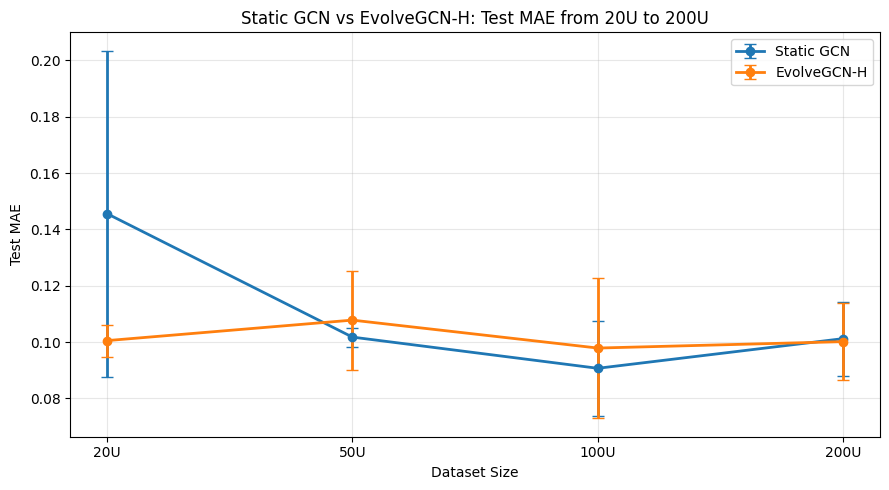

In [12]:
plot_metric_with_errorbars(
    summary_df=graph_summary,
    metric_mean="test_mae_mean",
    metric_std="test_mae_std",
    ylabel="Test MAE",
    title="Static GCN vs EvolveGCN-H: Test MAE from 20U to 200U",
    models=graph_models,
)

## 10. Test RMSE Scaling: Static GCN vs EvolveGCN-H

RMSE penalizes large prediction errors more strongly than MAE.

This plot helps us check whether one model occasionally makes larger mistakes than the other.

Lower Test RMSE is better.

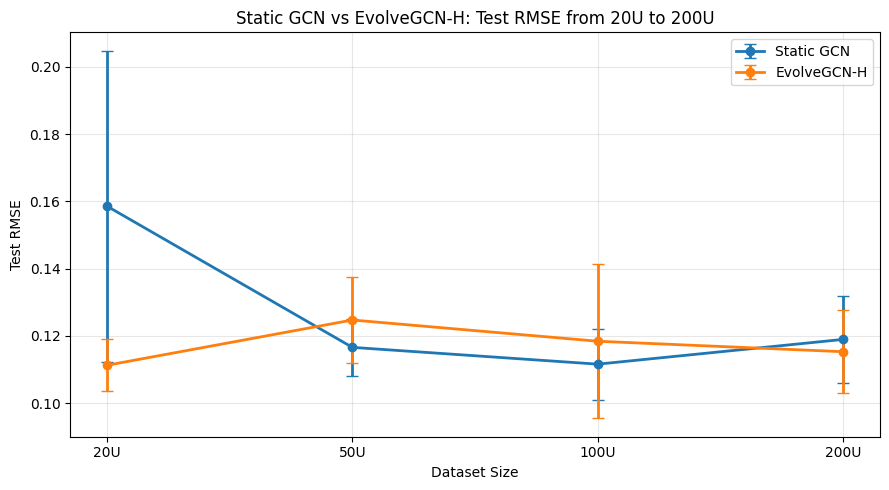

In [13]:
plot_metric_with_errorbars(
    summary_df=graph_summary,
    metric_mean="test_rmse_mean",
    metric_std="test_rmse_std",
    ylabel="Test RMSE",
    title="Static GCN vs EvolveGCN-H: Test RMSE from 20U to 200U",
    models=graph_models,
)

## 11. Direct Improvement: Static GCN vs EvolveGCN-H

To directly compare the two graph models, we calculate:

Static GCN Test MAE - EvolveGCN-H Test MAE

Interpretation:

- Positive value: EvolveGCN-H performs better.
- Negative value: Static GCN performs better.
- Near zero: both models perform similarly.

This comparison is useful because it directly answers whether temporal graph modeling improves over the static graph model.

In [14]:
pivot_mae = graph_summary.pivot(
    index="dataset_size",
    columns="model",
    values="test_mae_mean",
).reset_index()

pivot_mae["static_minus_evolvegcn_mae"] = (
    pivot_mae["Static GCN"] - pivot_mae["EvolveGCN-H"]
)

pivot_mae["relative_improvement_percent"] = (
    pivot_mae["static_minus_evolvegcn_mae"] / pivot_mae["Static GCN"] * 100
)

pivot_mae

model,dataset_size,EvolveGCN-H,Static GCN,static_minus_evolvegcn_mae,relative_improvement_percent
0,20U,0.100515,0.145589,0.045074,30.959686
1,50U,0.107791,0.101764,-0.006027,-5.922199
2,100U,0.097874,0.090691,-0.007183,-7.920301
3,200U,0.100153,0.101222,0.001069,1.056424


In [15]:
for _, row in pivot_mae.iterrows():
    dataset_size = row["dataset_size"]
    difference = row["static_minus_evolvegcn_mae"]
    percent = row["relative_improvement_percent"]

    if difference > 0:
        print(
            f"{dataset_size}: EvolveGCN-H improves over Static GCN by "
            f"{difference:.5f} MAE ({percent:.2f}%)."
        )
    elif difference < 0:
        print(
            f"{dataset_size}: Static GCN performs better than EvolveGCN-H by "
            f"{abs(difference):.5f} MAE ({abs(percent):.2f}%)."
        )
    else:
        print(f"{dataset_size}: Static GCN and EvolveGCN-H have equal mean Test MAE.")

20U: EvolveGCN-H improves over Static GCN by 0.04507 MAE (30.96%).
50U: Static GCN performs better than EvolveGCN-H by 0.00603 MAE (5.92%).
100U: Static GCN performs better than EvolveGCN-H by 0.00718 MAE (7.92%).
200U: EvolveGCN-H improves over Static GCN by 0.00107 MAE (1.06%).


## 12. Focus on the Final 200U Experiments

The 200U experiments are currently the most important because they use the largest dataset size tested so far.

This section focuses only on 200U and compares:

- Static GCN
- EvolveGCN-H

This is the cleanest current graph-model comparison.

In [16]:
final_200_graph = graph_df[graph_df["dataset_size"] == "200U"].copy()
final_200_graph = final_200_graph.sort_values(["seed", "model", "experiment_name"])

final_200_graph[display_columns]

,dataset_size,model,seed,train_mae,val_mae,test_mae,test_rmse,best_epoch,trainable_parameters,experiment_name
18,200U,EvolveGCN-H,42,0.095715,0.095976,0.097584,0.110997,8.0,3409153.0,evolvegcn_h_200u_seed42_final32
21,200U,Static GCN,42,0.120002,0.097280,0.101360,0.124214,2.0,4161.0,static_gcn_200u_seed42_final32
19,200U,EvolveGCN-H,123,0.102184,0.077642,0.088032,0.105713,5.0,3409153.0,evolvegcn_h_200u_seed123_final32
22,200U,Static GCN,123,0.102401,0.075385,0.088001,0.104318,35.0,4161.0,static_gcn_200u_seed123_final32
20,200U,EvolveGCN-H,2025,0.101730,0.078359,0.114842,0.129109,5.0,3409153.0,evolvegcn_h_200u_seed2025_final32
23,200U,Static GCN,2025,0.094843,0.086559,0.114305,0.128273,27.0,4161.0,static_gcn_200u_seed2025_final32


In [17]:
final_200_graph_summary = (
    final_200_graph
    .groupby("model")
    .agg(
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_rmse_mean=("test_rmse", "mean"),
        test_rmse_std=("test_rmse", "std"),
        val_mae_mean=("val_mae", "mean"),
        val_mae_std=("val_mae", "std"),
        best_epoch_mean=("best_epoch", "mean"),
        best_epoch_std=("best_epoch", "std"),
        trainable_parameters_mean=("trainable_parameters", "mean"),
        runs=("test_mae", "count"),
    )
    .reset_index()
    .sort_values("test_mae_mean")
)

final_200_graph_summary

,model,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,val_mae_mean,val_mae_std,best_epoch_mean,best_epoch_std,trainable_parameters_mean,runs
0,EvolveGCN-H,0.100153,0.013588,0.115273,0.01227,0.083992,0.010384,6.000000,1.732051,3409153.0,3
1,Static GCN,0.101222,0.013153,0.118935,0.01282,0.086408,0.010948,21.333333,17.214335,4161.0,3


## 13. Final 200U Bar Plot

This bar plot compares the average Test MAE of Static GCN and EvolveGCN-H on the 200U dataset.

The error bars show variation across seeds.

This is one of the most important plots for the meeting because it summarizes the strongest current experiment setting.

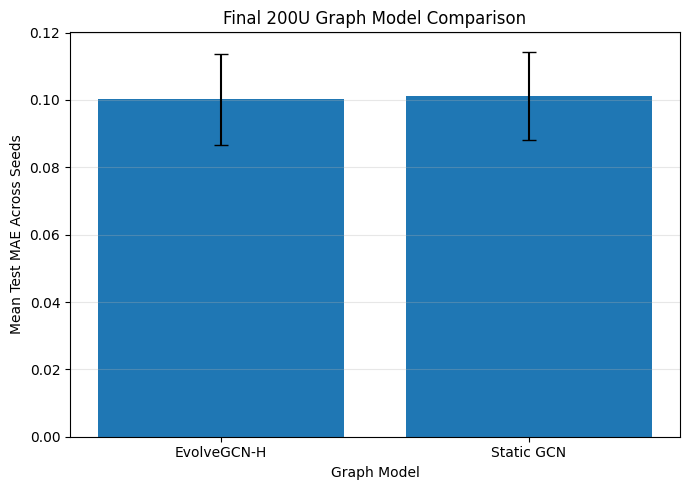

In [18]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_200_graph_summary["model"],
    final_200_graph_summary["test_mae_mean"],
    yerr=final_200_graph_summary["test_mae_std"],
    capsize=5,
)

plt.xlabel("Graph Model")
plt.ylabel("Mean Test MAE Across Seeds")
plt.title("Final 200U Graph Model Comparison")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Mean Baseline as Sanity Check

The mean baseline is not a graph model.

It predicts the average `Omega_m` value from the training set.

It is useful only as a sanity check because it tells us whether the graph models outperform a very simple non-graph prediction rule.

However, the main thesis comparison should remain focused on:

Static GCN vs EvolveGCN-H

In [19]:
baseline_df = df[df["model"] == "Mean Baseline"].copy()

baseline_summary = (
    baseline_df
    .groupby(["dataset_size", "model"], observed=True)
    .agg(
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_rmse_mean=("test_rmse", "mean"),
        test_rmse_std=("test_rmse", "std"),
        runs=("test_mae", "count"),
    )
    .reset_index()
    .sort_values(["dataset_size", "model"])
)

baseline_summary

,dataset_size,model,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,runs
0,20U,Mean Baseline,0.111349,0.035135,0.119858,0.028601,3
1,50U,Mean Baseline,0.113891,0.020839,0.128620,0.019051,3
2,100U,Mean Baseline,0.088834,0.015155,0.109982,0.010417,3
3,200U,Mean Baseline,0.100765,0.012250,0.117138,0.012477,3


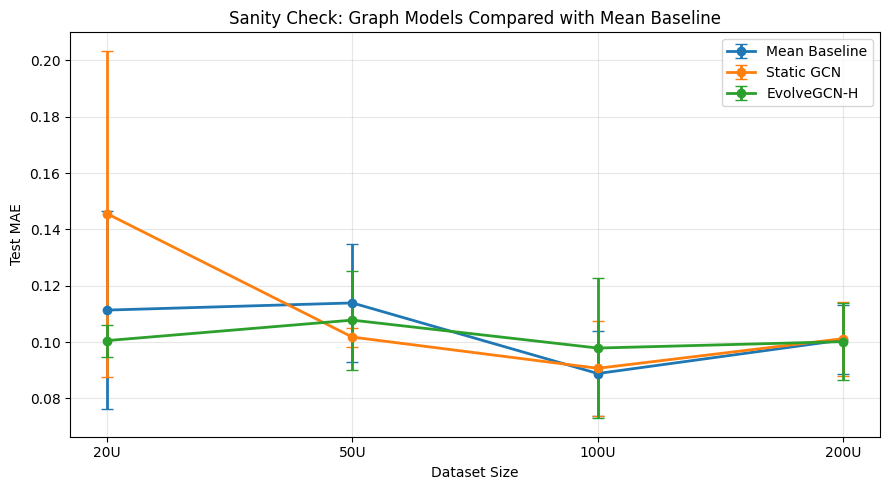

,dataset_size,model,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,runs
0,20U,EvolveGCN-H,0.100515,0.005647,0.111242,0.007743,3
1,20U,Mean Baseline,0.111349,0.035135,0.119858,0.028601,3
2,20U,Static GCN,0.145589,0.057820,0.158569,0.046234,3
3,50U,EvolveGCN-H,0.107791,0.017550,0.124706,0.012753,3
4,50U,Mean Baseline,0.113891,0.020839,0.128620,0.019051,3
5,50U,Static GCN,0.101764,0.003397,0.116567,0.008410,3
6,100U,EvolveGCN-H,0.097874,0.024946,0.118388,0.022933,3
7,100U,Mean Baseline,0.088834,0.015155,0.109982,0.010417,3
8,100U,Static GCN,0.090691,0.016841,0.111572,0.010549,3
9,200U,EvolveGCN-H,0.100153,0.013588,0.115273,0.012270,3


In [20]:
# For the sanity-check plot, use the already-clean dataframe.
# This includes:
# - Mean Baseline
# - Static GCN with the correct architecture
# - EvolveGCN-H with the correct architecture

sanity_df = pd.concat(
    [
        df[df["model"] == "Mean Baseline"].copy(),
        graph_df.copy(),
    ],
    ignore_index=True,
)

all_summary = (
    sanity_df
    .groupby(["dataset_size", "model"], observed=True)
    .agg(
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_rmse_mean=("test_rmse", "mean"),
        test_rmse_std=("test_rmse", "std"),
        runs=("test_mae", "count"),
    )
    .reset_index()
    .sort_values(["dataset_size", "model"])
)

plt.figure(figsize=(9, 5))

for model_name in ["Mean Baseline", "Static GCN", "EvolveGCN-H"]:
    model_data = all_summary[all_summary["model"] == model_name].copy()

    plt.errorbar(
        model_data["dataset_size"].astype(str),
        model_data["test_mae_mean"],
        yerr=model_data["test_mae_std"],
        marker="o",
        capsize=4,
        linewidth=2,
        label=model_name,
    )

plt.xlabel("Dataset Size")
plt.ylabel("Test MAE")
plt.title("Sanity Check: Graph Models Compared with Mean Baseline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

all_summary

## 15. How to Explain the Mean Baseline



The mean baseline is included only as a sanity check. It does not use graph structure, halo properties, or temporal evolution. The real graph-learning comparison is between Static GCN and EvolveGCN-H.

Static GCN checks whether the final graph structure is useful.

EvolveGCN-H checks whether temporal graph evolution adds useful information beyond the final static graph.

Therefore, the mean baseline is useful for internal validation, but the scientific comparison remains graph-based.

## 16. Best Epoch Analysis

The best epoch tells us when the model achieved its best validation performance.

This is useful because it gives insight into training stability.

If the best epoch is very early, it may suggest:

- fast convergence,
- possible overfitting,
- small dataset size,
- or model capacity being high compared with the available data.

If the best epoch is later, it may suggest that the model needed more training to learn useful graph structure.

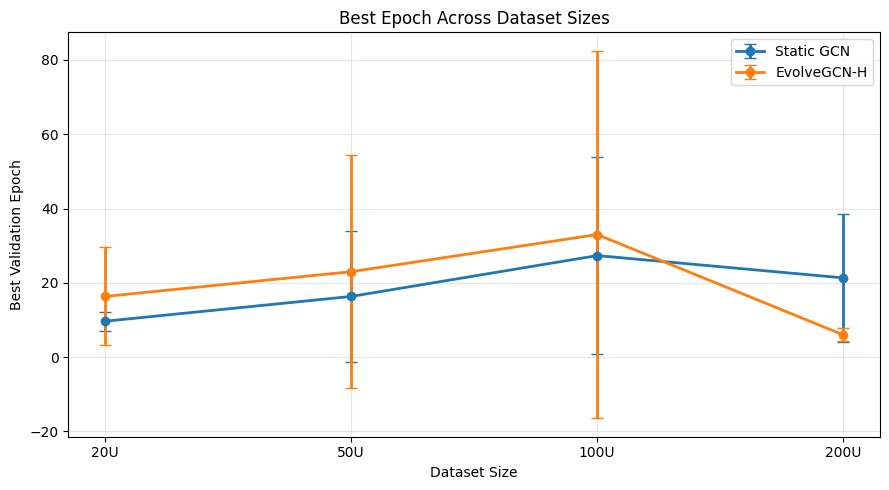

In [21]:
plot_metric_with_errorbars(
    summary_df=graph_summary,
    metric_mean="best_epoch_mean",
    metric_std="best_epoch_std",
    ylabel="Best Validation Epoch",
    title="Best Epoch Across Dataset Sizes",
    models=graph_models,
)

## 17. Model Complexity

The number of trainable parameters helps us understand model complexity.

This is important because:

- Static GCN is simpler.
- EvolveGCN-H is more complex.
- Larger models can overfit when the dataset is small.
- If a larger temporal model does not outperform the static model, it may need better tuning or a different temporal architecture.

In [22]:
parameter_table = (
    graph_df
    .groupby(["dataset_size", "model"], observed=True)
    .agg(
        trainable_parameters_mean=("trainable_parameters", "mean"),
        trainable_parameters_min=("trainable_parameters", "min"),
        trainable_parameters_max=("trainable_parameters", "max"),
        runs=("test_mae", "count"),
    )
    .reset_index()
    .sort_values(["dataset_size", "model"])
)

parameter_table

,dataset_size,model,trainable_parameters_mean,trainable_parameters_min,trainable_parameters_max,runs
0,20U,EvolveGCN-H,3409153.0,3409153.0,3409153.0,3
1,20U,Static GCN,4161.0,4161.0,4161.0,3
2,50U,EvolveGCN-H,3409153.0,3409153.0,3409153.0,3
3,50U,Static GCN,4161.0,4161.0,4161.0,3
4,100U,EvolveGCN-H,3409153.0,3409153.0,3409153.0,3
5,100U,Static GCN,4161.0,4161.0,4161.0,3
6,200U,EvolveGCN-H,3409153.0,3409153.0,3409153.0,3
7,200U,Static GCN,4161.0,4161.0,4161.0,3


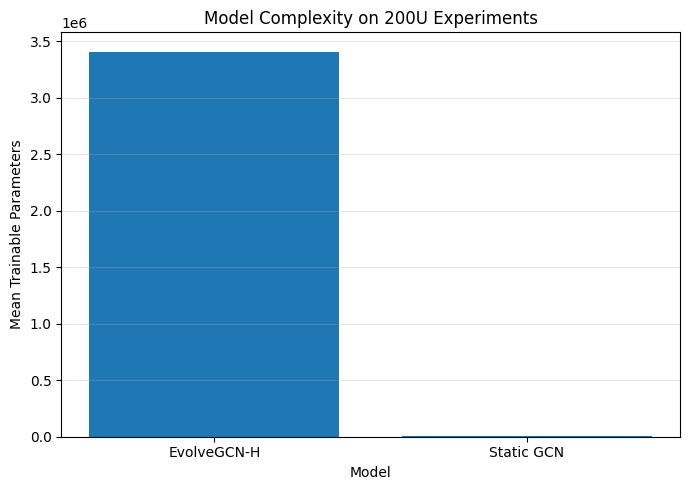

In [23]:
params_200 = parameter_table[parameter_table["dataset_size"] == "200U"].copy()

plt.figure(figsize=(7, 5))

plt.bar(
    params_200["model"],
    params_200["trainable_parameters_mean"],
)

plt.xlabel("Model")
plt.ylabel("Mean Trainable Parameters")
plt.title("Model Complexity on 200U Experiments")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Prediction Error Stability Across Seeds

This section checks whether the models are stable across different random seeds.

A model with lower average error but very high standard deviation may be less reliable.

A model with slightly higher average error but lower standard deviation may be more stable.

This matters because the dataset is still relatively small for deep learning.

In [24]:
seed_stability = (
    graph_df
    .groupby(["dataset_size", "model"], observed=True)
    .agg(
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        test_mae_min=("test_mae", "min"),
        test_mae_max=("test_mae", "max"),
        test_rmse_mean=("test_rmse", "mean"),
        test_rmse_std=("test_rmse", "std"),
        runs=("test_mae", "count"),
    )
    .reset_index()
    .sort_values(["dataset_size", "model"])
)

seed_stability

,dataset_size,model,test_mae_mean,test_mae_std,test_mae_min,test_mae_max,test_rmse_mean,test_rmse_std,runs
0,20U,EvolveGCN-H,0.100515,0.005647,0.094632,0.105891,0.111242,0.007743,3
1,20U,Static GCN,0.145589,0.057820,0.103511,0.211519,0.158569,0.046234,3
2,50U,EvolveGCN-H,0.107791,0.017550,0.093515,0.127385,0.124706,0.012753,3
3,50U,Static GCN,0.101764,0.003397,0.099470,0.105666,0.116567,0.008410,3
4,100U,EvolveGCN-H,0.097874,0.024946,0.079260,0.126219,0.118388,0.022933,3
5,100U,Static GCN,0.090691,0.016841,0.075015,0.108495,0.111572,0.010549,3
6,200U,EvolveGCN-H,0.100153,0.013588,0.088032,0.114842,0.115273,0.012270,3
7,200U,Static GCN,0.101222,0.013153,0.088001,0.114305,0.118935,0.012820,3


## 19. Best Model Per Dataset Size

This table identifies the best graph model for each dataset size based on mean Test MAE across seeds.

This helps summarize whether Static GCN or EvolveGCN-H is currently stronger at each scale.

In [25]:
best_graph_per_size = (
    graph_summary
    .sort_values(["dataset_size", "test_mae_mean"])
    .groupby("dataset_size", observed=True)
    .head(1)
    .reset_index(drop=True)
)

best_graph_per_size[
    [
        "dataset_size",
        "model",
        "test_mae_mean",
        "test_mae_std",
        "test_rmse_mean",
        "test_rmse_std",
        "runs",
    ]
]

,dataset_size,model,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,runs
0,20U,EvolveGCN-H,0.100515,0.005647,0.111242,0.007743,3
1,50U,Static GCN,0.101764,0.003397,0.116567,0.008410,3
2,100U,Static GCN,0.090691,0.016841,0.111572,0.010549,3
3,200U,EvolveGCN-H,0.100153,0.013588,0.115273,0.012270,3


## 20. Generate Automatic Interpretation Text

The following cell prints a short interpretation that can be used during a meeting.

This is not a final thesis conclusion.  
It is a current progress interpretation based on the available experiments.

In [26]:
print("CURRENT GRAPH-MODEL INTERPRETATION")
print("=" * 80)

for _, row in pivot_mae.iterrows():
    dataset_size = row["dataset_size"]
    static_mae = row["Static GCN"]
    evolve_mae = row["EvolveGCN-H"]
    difference = row["static_minus_evolvegcn_mae"]

    print(f"\nDataset size: {dataset_size}")
    print(f"Static GCN mean Test MAE:    {static_mae:.5f}")
    print(f"EvolveGCN-H mean Test MAE:   {evolve_mae:.5f}")

    if difference > 0:
        print("Interpretation: EvolveGCN-H is better on average for this dataset size.")
    elif difference < 0:
        print("Interpretation: Static GCN is better on average for this dataset size.")
    else:
        print("Interpretation: Both models have the same average Test MAE.")

print("\nOverall note:")
print(
    "The graph pipeline is working. The next research step is not only scaling, "
    "but also improving or comparing temporal graph architectures."
)

CURRENT GRAPH-MODEL INTERPRETATION

Dataset size: 20U
Static GCN mean Test MAE:    0.14559
EvolveGCN-H mean Test MAE:   0.10052
Interpretation: EvolveGCN-H is better on average for this dataset size.

Dataset size: 50U
Static GCN mean Test MAE:    0.10176
EvolveGCN-H mean Test MAE:   0.10779
Interpretation: Static GCN is better on average for this dataset size.

Dataset size: 100U
Static GCN mean Test MAE:    0.09069
EvolveGCN-H mean Test MAE:   0.09787
Interpretation: Static GCN is better on average for this dataset size.

Dataset size: 200U
Static GCN mean Test MAE:    0.10122
EvolveGCN-H mean Test MAE:   0.10015
Interpretation: EvolveGCN-H is better on average for this dataset size.

Overall note:
The graph pipeline is working. The next research step is not only scaling, but also improving or comparing temporal graph architectures.


## 21. Save Notebook Tables

The following cell saves the clean analysis tables generated in this notebook.

These files can later be used in:

- thesis figures,
- presentation slides,
- progress reports,
- final experiment documentation.

In [29]:
notebook_tables_dir = OUTPUTS_DIR / "notebook_tables"
notebook_tables_dir.mkdir(parents=True, exist_ok=True)

graph_summary_path = notebook_tables_dir / "graph_models_20u_to_200u_summary.csv"
final_200_graph_summary_path = notebook_tables_dir / "final_200u_graph_model_summary.csv"
improvement_path = notebook_tables_dir / "static_vs_evolvegcn_improvement.csv"
baseline_summary_path = notebook_tables_dir / "mean_baseline_sanity_summary.csv"
seed_stability_path = notebook_tables_dir / "seed_stability_summary.csv"
best_graph_per_size_path = notebook_tables_dir / "best_graph_model_per_dataset_size.csv"

graph_summary.to_csv(graph_summary_path, index=False)
final_200_graph_summary.to_csv(final_200_graph_summary_path, index=False)
pivot_mae.to_csv(improvement_path, index=False)
baseline_summary.to_csv(baseline_summary_path, index=False)
seed_stability.to_csv(seed_stability_path, index=False)
best_graph_per_size.to_csv(best_graph_per_size_path, index=False)

print("Saved notebook tables:")
print(graph_summary_path)
print(final_200_graph_summary_path)
print(improvement_path)
print(baseline_summary_path)
print(seed_stability_path)
print(best_graph_per_size_path)

Saved notebook tables:
<REPO_ROOT>/outputs/notebook_tables/graph_models_20u_to_200u_summary.csv
<REPO_ROOT>/outputs/notebook_tables/final_200u_graph_model_summary.csv
<REPO_ROOT>/outputs/notebook_tables/static_vs_evolvegcn_improvement.csv
<REPO_ROOT>/outputs/notebook_tables/mean_baseline_sanity_summary.csv
<REPO_ROOT>/outputs/notebook_tables/seed_stability_summary.csv
<REPO_ROOT>/outputs/notebook_tables/best_graph_model_per_dataset_size.csv


## 22. Final Meeting Summary

The current pipeline is complete up to 200 universes.

Completed steps:

1. Downloaded CAMELS-SIMBA raw hlist files.
2. Verified that every universe has the required five snapshots.
3. Inspected and validated `Omega_m` targets.
4. Built static graph datasets.
5. Built temporal graph sequence datasets.
6. Validated the processed datasets.
7. Trained Static GCN models.
8. Trained EvolveGCN-H temporal models.
9. Repeated experiments across multiple random seeds.
10. Compared results from 20U to 200U.

The most important scientific comparison is:

Static GCN vs EvolveGCN-H

The mean baseline is included only as a sanity check.

The current results show that the graph-learning pipeline is working, but the temporal model does not yet consistently dominate the static model. This is scientifically useful because it suggests that the next step should focus on temporal model improvement, ablation studies, and stronger temporal graph architectures.

## 23. Next Research Steps

The next meaningful steps are:

### 1. Keep Static GCN as the main graph benchmark

Static GCN is simple, clear, and graph-based.  
It should remain the main benchmark for comparing temporal models.

### 2. Improve EvolveGCN-H

Possible improvements:

- tune hidden dimension,
- tune dropout,
- compare one-layer vs two-layer versions,
- compare mean temporal pooling vs last-snapshot pooling,
- inspect prediction errors,
- check overfitting behavior.

### 3. Add another temporal model later

Possible future models:

- EvolveGCN-O,
- GRU over graph embeddings,
- TGAT-style temporal attention,
- temporal pooling baseline.

### 4. Scale beyond 200U after the 200U story is clean

Scaling to 500U or 1000U is useful, but the model comparison and explanation should first be clean at 200U.